# The AI Era: What 49,000 Developers Reveal About Trust, Fear, and Job Satisfaction

**Dataset:** Stack Overflow Developer Survey 2025  
**Author:** Gustavo Jannuzzi  
**Process:** CRISP-DM

---

## Business Understanding

AI tools have become central to software development in 2025. But how do developers *really* feel about them? Are they embracing AI, or quietly resisting it? Do developers who use AI feel more satisfied at work — or more threatened?

This notebook investigates four concrete business questions using the Stack Overflow Developer Survey 2025 (49,191 respondents across 180+ countries):

1. **How widespread is AI tool adoption among developers in 2025?**
2. **Do developers trust the AI tools they use — and how does that relate to job satisfaction?**
3. **Who fears AI will take their job? What profiles are most threatened?**
4. **Can we predict whether a developer will have high job satisfaction using their profile and AI-related attributes?**

---
## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
BRAND_COLOR = '#F48024'  # Stack Overflow orange

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
df = pd.read_csv(
    'stack-overflow-developer-survey-2025/survey_results_public.csv',
    low_memory=False
)

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nKey columns used in this analysis:')
key_cols = [
    'AISelect', 'AISent', 'AIAcc', 'AIThreat',
    'JobSat', 'YearsCode', 'WorkExp',
    'RemoteWork', 'EdLevel', 'OrgSize', 'DevType'
]
for col in key_cols:
    n_valid = df[col].notna().sum()
    print(f'  {col}: {n_valid:,} valid responses ({n_valid/len(df)*100:.1f}%)')

Dataset shape: 49,191 rows x 172 columns

Key columns used in this analysis:
  AISelect: 33,720 valid responses (68.5%)
  AISent: 33,467 valid responses (68.0%)
  AIAcc: 33,297 valid responses (67.7%)
  AIThreat: 36,078 valid responses (73.3%)
  JobSat: 26,670 valid responses (54.2%)
  YearsCode: 43,042 valid responses (87.5%)
  WorkExp: 42,893 valid responses (87.2%)
  RemoteWork: 33,780 valid responses (68.7%)
  EdLevel: 48,149 valid responses (97.9%)
  OrgSize: 34,178 valid responses (69.5%)
  DevType: 43,680 valid responses (88.8%)


---
## 2. Data Understanding (Exploratory Data Analysis)

In [3]:
df['YearsCode'] = pd.to_numeric(df['YearsCode'], errors='coerce')
df['WorkExp'] = pd.to_numeric(df['WorkExp'], errors='coerce')

df[['YearsCode', 'WorkExp', 'JobSat', 'ConvertedCompYearly']].describe().round(2)

,YearsCode,WorkExp,JobSat,ConvertedCompYearly
count,43042.00,42893.00,26670.0,23947.00
mean,16.57,13.37,7.2,101761.54
std,11.79,10.80,2.0,461756.90
min,1.00,1.00,0.0,1.00
25%,8.00,5.00,6.0,38171.00
50%,14.00,10.00,8.0,75320.00
75%,24.00,20.00,8.0,120596.00
max,100.00,100.00,10.0,50000000.00


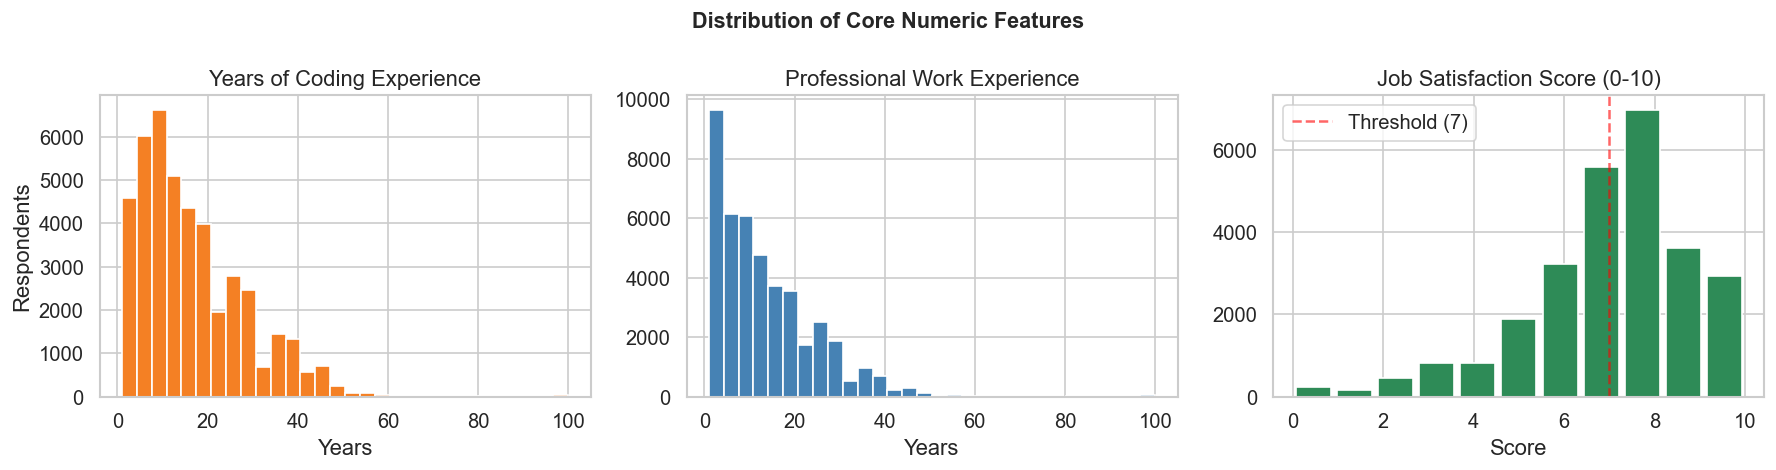

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['YearsCode'].dropna(), bins=30, color=BRAND_COLOR, edgecolor='white')
axes[0].set_title('Years of Coding Experience')
axes[0].set_xlabel('Years')
axes[0].set_ylabel('Respondents')

axes[1].hist(df['WorkExp'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Professional Work Experience')
axes[1].set_xlabel('Years')

axes[2].hist(df['JobSat'].dropna(), bins=11, color='seagreen', edgecolor='white', rwidth=0.85)
axes[2].set_title('Job Satisfaction Score (0-10)')
axes[2].set_xlabel('Score')
axes[2].axvline(7, color='red', linestyle='--', alpha=0.6, label='Threshold (7)')
axes[2].legend()

plt.suptitle('Distribution of Core Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_distributions.png', bbox_inches='tight')
plt.show()

**Observations:**
- Coding experience is right-skewed: most respondents have between 3-20 years of experience.
- Work experience follows a similar pattern.
- Job satisfaction is strongly skewed toward higher values — 71.6% rated satisfaction >= 7/10. The red dashed line at 7 marks the binary classification threshold used in the ML task.

---
## 3. Data Preparation (Cleaning)

The survey mixes:
- **Numeric free-text fields** (`YearsCode`, `WorkExp`): cleaned with `pd.to_numeric(..., errors='coerce')`.
- **Ordinal categoricals** (`AISelect`, `AISent`, `AIAcc`, `RemoteWork`, `EdLevel`, `OrgSize`): mapped to integers reflecting meaningful order.
- **Missing values**: dropped row-wise only for the ML subset; EDA uses `.dropna()` per question to maximize sample size.

In [5]:
# Ordinal encoding — each map reflects a meaningful low-to-high ordering

AI_SELECT_ORDER = {
    "No, and I don't plan to": 0,
    'No, but I plan to soon': 1,
    'Yes, I use AI tools monthly or infrequently': 2,
    'Yes, I use AI tools weekly': 3,
    'Yes, I use AI tools daily': 4,
}

AI_SENT_ORDER = {
    'Very unfavorable': 0, 'Unfavorable': 1,
    'Unsure': 2, 'Indifferent': 2,
    'Favorable': 3, 'Very favorable': 4,
}

AI_ACC_ORDER = {
    'Highly distrust': 0, 'Somewhat distrust': 1,
    'Neither trust nor distrust': 2, 'Somewhat trust': 3, 'Highly trust': 4,
}

REMOTE_ORDER = {
    'In-person': 0,
    'Hybrid (some remote, leans heavy to in-person)': 1,
    'Hybrid (some in-person, leans heavy to flexibility)': 2,
    'Your choice (very flexible, you can come in when you want or just as needed)': 3,
    'Remote': 4,
}

ED_ORDER = {
    'Primary/elementary school': 0,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 1,
    'Some college/university study without earning a degree': 2,
    'Associate degree (A.A., A.S., etc.)': 3,
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": 4,
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 6,
}

AI_THREAT_ORDER = {'No': 0, "I'm not sure": 1, 'Yes': 2}

ORG_ORDER = {
    'Just me - I am a freelancer, sole proprietor, etc.': 0,
    '2 to 9 employees': 1, '10 to 19 employees': 2,
    '20 to 99 employees': 3, '100 to 499 employees': 4,
    '500 to 999 employees': 5, '1,000 to 4,999 employees': 6,
    '5,000 to 9,999 employees': 7, '10,000 or more employees': 8,
}

df['AISelect_enc']    = df['AISelect'].map(AI_SELECT_ORDER)
df['AISent_enc']      = df['AISent'].map(AI_SENT_ORDER)
df['AIAcc_enc']       = df['AIAcc'].map(AI_ACC_ORDER)
df['RemoteWork_enc']  = df['RemoteWork'].map(REMOTE_ORDER)
df['EdLevel_enc']     = df['EdLevel'].map(ED_ORDER)
df['OrgSize_enc']     = df['OrgSize'].map(ORG_ORDER)
df['AIThreat_enc']    = df['AIThreat'].map(AI_THREAT_ORDER)

print('Encodings applied.')
df[['AISelect', 'AISelect_enc', 'AISent', 'AISent_enc']].dropna().head(3)

Encodings applied.


,AISelect,AISelect_enc,AISent,AISent_enc
0,"Yes, I use AI tools monthly or infrequently",2.0,Indifferent,2.0
1,"Yes, I use AI tools weekly",3.0,Indifferent,2.0
2,"Yes, I use AI tools daily",4.0,Favorable,3.0


---
## 4. Analysis and Visualization

### Question 1 — How widespread is AI tool adoption among developers in 2025?

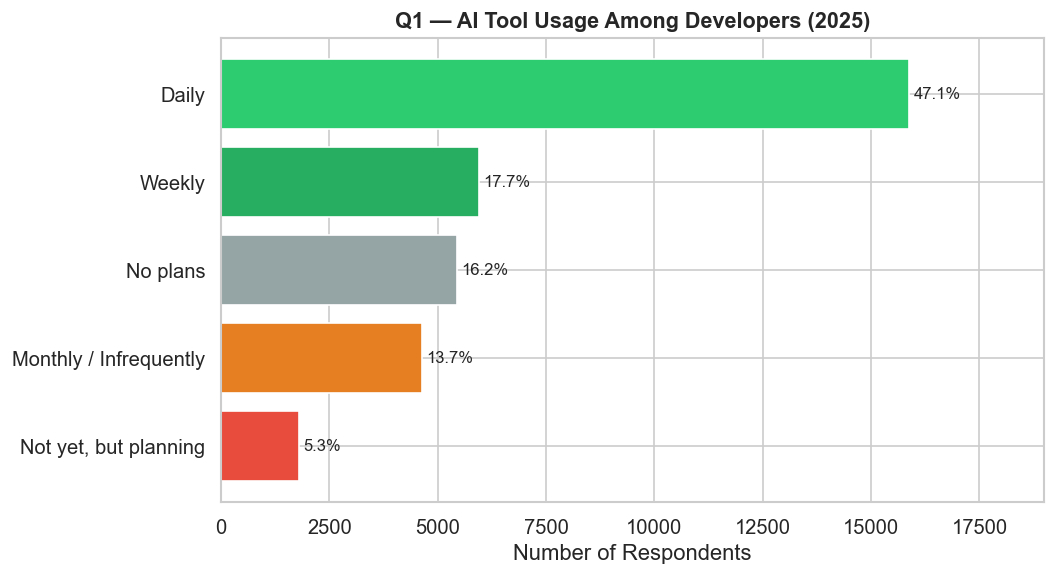

Key finding: 78.5% of developers use AI tools in some form.
Daily users: 15,883 (47.1%)


In [6]:
ai_counts = df['AISelect'].value_counts()
total_ai = ai_counts.sum()

label_map = {
    'Yes, I use AI tools daily': 'Daily',
    'Yes, I use AI tools weekly': 'Weekly',
    'Yes, I use AI tools monthly or infrequently': 'Monthly / Infrequently',
    'No, but I plan to soon': 'Not yet, but planning',
    "No, and I don't plan to": 'No plans',
}
ai_plot = ai_counts.rename(index=label_map)

colors = ['#2ecc71', '#27ae60', '#95a5a6', '#e67e22', '#e74c3c']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(ai_plot.index[::-1], ai_plot.values[::-1], color=colors[::-1])

for bar in bars:
    pct = bar.get_width() / total_ai * 100
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Number of Respondents')
ax.set_title('Q1 — AI Tool Usage Among Developers (2025)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 19000)
plt.tight_layout()
plt.savefig('fig_q1_ai_adoption.png', bbox_inches='tight')
plt.show()

using_pct = ai_counts[ai_counts.index.str.startswith('Yes')].sum() / total_ai * 100
print(f'Key finding: {using_pct:.1f}% of developers use AI tools in some form.')
print(f"Daily users: {ai_counts['Yes, I use AI tools daily']:,} "
      f"({ai_counts['Yes, I use AI tools daily']/total_ai*100:.1f}%)")

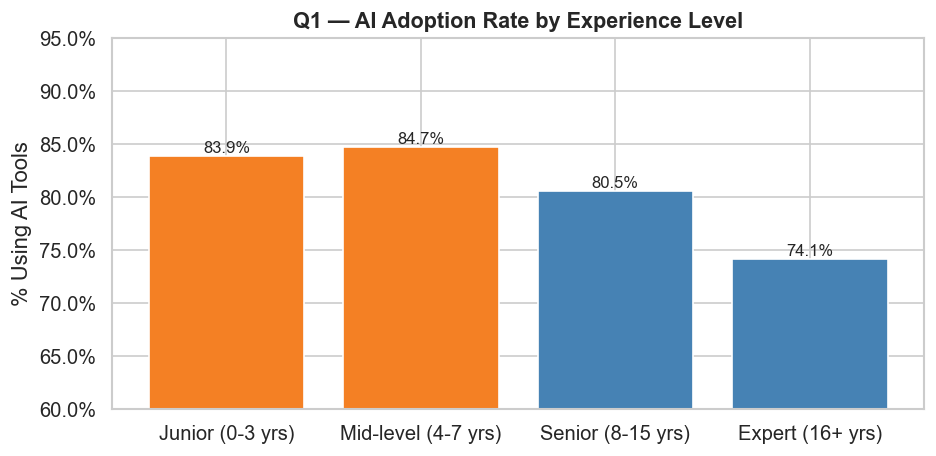

In [7]:
exp_bands = {
    'Junior (0-3 yrs)': (0, 3),
    'Mid-level (4-7 yrs)': (4, 7),
    'Senior (8-15 yrs)': (8, 15),
    'Expert (16+ yrs)': (16, 100),
}

rows = []
for label, (lo, hi) in exp_bands.items():
    mask = df['YearsCode'].between(lo, hi)
    sub = df.loc[mask, 'AISelect'].dropna()
    rows.append({'Experience': label,
                 'Pct Using AI': sub.str.startswith('Yes').sum() / len(sub) * 100})

exp_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4))
bar_cols = [BRAND_COLOR, BRAND_COLOR, 'steelblue', 'steelblue']
ax.bar(exp_df['Experience'], exp_df['Pct Using AI'], color=bar_cols, edgecolor='white')
ax.set_ylabel('% Using AI Tools')
ax.set_title('Q1 — AI Adoption Rate by Experience Level', fontsize=13, fontweight='bold')
ax.set_ylim(60, 95)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig_q1_adoption_by_exp.png', bbox_inches='tight')
plt.show()

**Key Findings — Q1:**
- **78.5%** of developers use AI tools in some capacity.
- **47.1%** use them daily — AI is now a core part of most developers' workflows.
- AI adoption is slightly higher among junior (83.9%) and mid-level (84.7%) developers compared to experts (74.1%), suggesting that newer developers are growing up with AI tools as a default.

---
### Question 2 — Do developers trust the AI tools they use? How does that relate to job satisfaction?

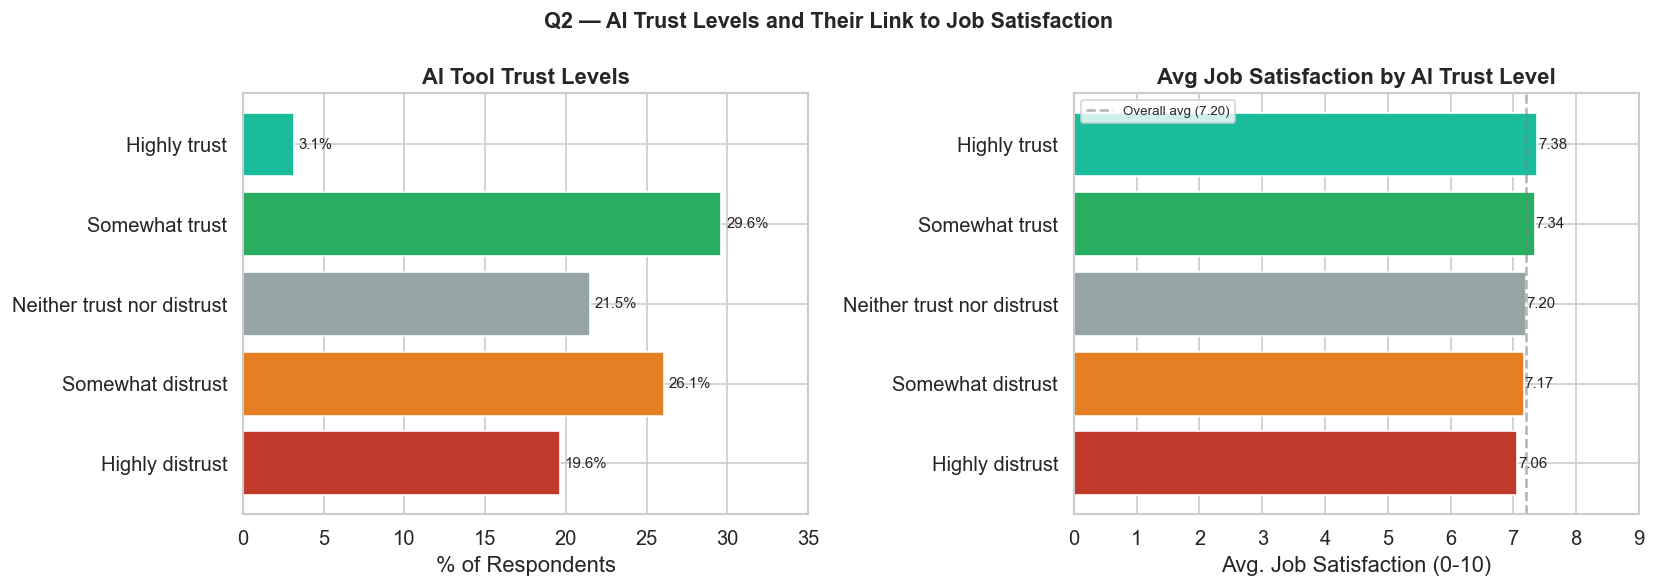

In [8]:
trust_order = ['Highly distrust', 'Somewhat distrust', 'Neither trust nor distrust',
               'Somewhat trust', 'Highly trust']
trust_counts = df['AIAcc'].value_counts().reindex(trust_order)
trust_pcts = trust_counts / trust_counts.sum() * 100
colors_trust = ['#c0392b', '#e67e22', '#95a5a6', '#27ae60', '#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(trust_order, trust_pcts, color=colors_trust, edgecolor='white')
for i, pct in enumerate(trust_pcts):
    axes[0].text(pct + 0.3, i, f'{pct:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('% of Respondents')
axes[0].set_title('AI Tool Trust Levels', fontweight='bold')
axes[0].set_xlim(0, 35)

sat_by_trust = df.groupby('AIAcc')['JobSat'].mean().reindex(trust_order)
axes[1].barh(trust_order, sat_by_trust, color=colors_trust, edgecolor='white')
for i, val in enumerate(sat_by_trust):
    axes[1].text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=9)
axes[1].set_xlabel('Avg. Job Satisfaction (0-10)')
axes[1].set_title('Avg Job Satisfaction by AI Trust Level', fontweight='bold')
axes[1].set_xlim(0, 9)
axes[1].axvline(7.20, color='grey', linestyle='--', alpha=0.6, label='Overall avg (7.20)')
axes[1].legend(fontsize=8)

plt.suptitle('Q2 — AI Trust Levels and Their Link to Job Satisfaction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q2_trust.png', bbox_inches='tight')
plt.show()

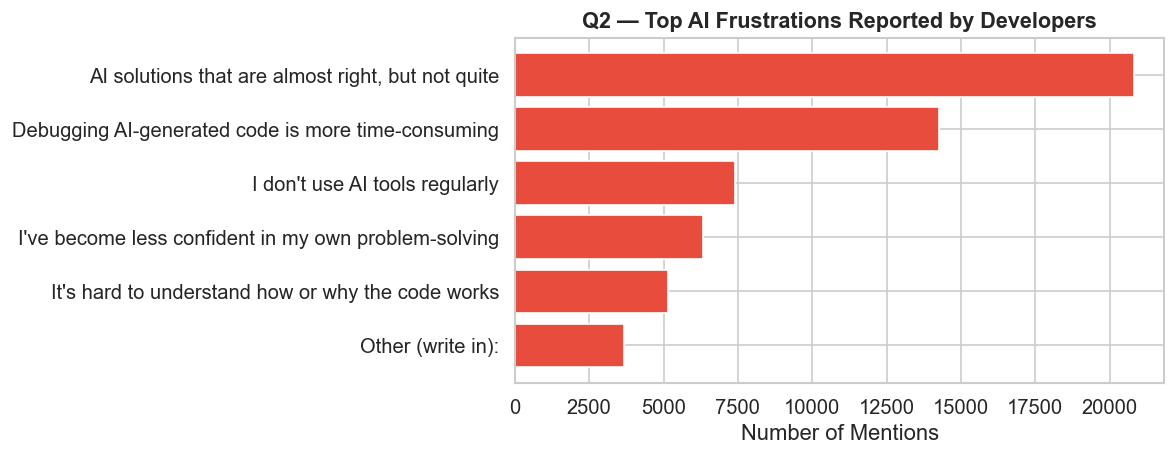

In [9]:
frustrations = (
    df['AIFrustration']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts()
    .head(6)
)
frustrations.index = (
    frustrations.index
    .str.replace('\u2019', "'")
    .str.replace('\u2018', "'")
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(frustrations.index[::-1], frustrations.values[::-1],
        color='#e74c3c', edgecolor='white')
ax.set_xlabel('Number of Mentions')
ax.set_title('Q2 — Top AI Frustrations Reported by Developers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q2_frustrations.png', bbox_inches='tight')
plt.show()

**Key Findings — Q2:**
- Despite 78.5% adoption, **only 32.7%** of developers trust AI tools (somewhat + highly trust).
- **45.7%** actively distrust AI outputs. This is the *use but verify* era.
- Developers who trust AI report slightly higher job satisfaction (7.38) vs. those who distrust it (7.06).
- The #1 frustration: *AI solutions that are almost right, but not quite* — the well-known last-mile problem.

---
### Question 3 — Who fears AI will take their job?

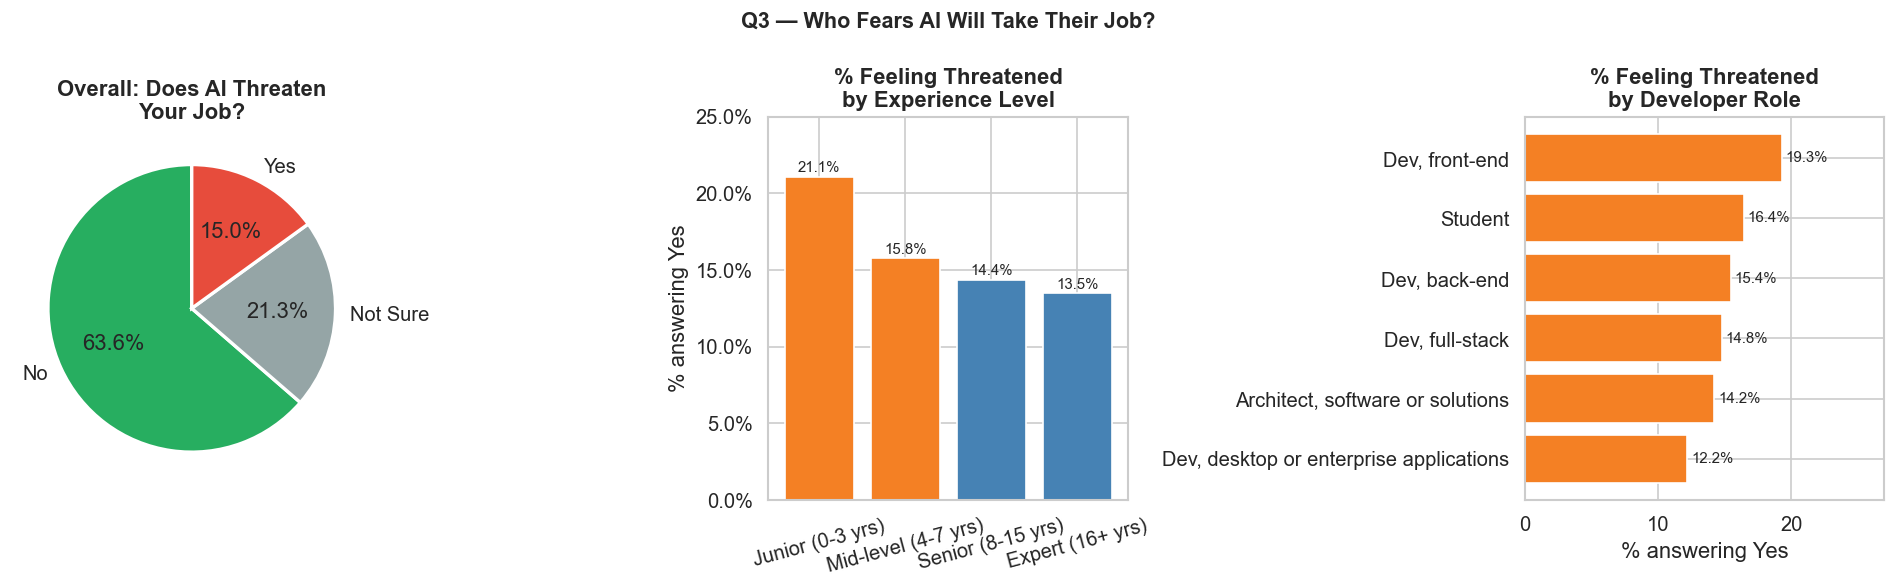

In [10]:
threat_counts = df['AIThreat'].value_counts()
threat_pcts = threat_counts / threat_counts.sum() * 100

exp_threat_rows = []
for label, (lo, hi) in exp_bands.items():
    mask = df['YearsCode'].between(lo, hi)
    sub = df.loc[mask, 'AIThreat'].dropna()
    exp_threat_rows.append({'Experience': label,
                            'Pct Threatened': (sub == 'Yes').sum() / len(sub) * 100})
threat_exp_df = pd.DataFrame(exp_threat_rows)

top_roles = df['DevType'].value_counts().head(6).index.tolist()
role_threat = {}
for role in top_roles:
    sub = df[df['DevType'] == role]['AIThreat'].dropna()
    role_threat[role] = (sub == 'Yes').sum() / len(sub) * 100
role_threat_s = pd.Series(role_threat).sort_values(ascending=False)
role_threat_s.index = role_threat_s.index.str.replace('Developer, ', 'Dev, ')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

wedge_colors = ['#27ae60', '#95a5a6', '#e74c3c']
axes[0].pie(
    threat_pcts.reindex(['No', "I'm not sure", 'Yes']),
    labels=['No', 'Not Sure', 'Yes'],
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall: Does AI Threaten\nYour Job?', fontweight='bold')

bar_c = [BRAND_COLOR if x > 15 else 'steelblue' for x in threat_exp_df['Pct Threatened']]
axes[1].bar(threat_exp_df['Experience'], threat_exp_df['Pct Threatened'],
            color=bar_c, edgecolor='white')
axes[1].set_title('% Feeling Threatened\nby Experience Level', fontweight='bold')
axes[1].set_ylabel('% answering Yes')
axes[1].set_ylim(0, 25)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

axes[2].barh(role_threat_s.index[::-1], role_threat_s.values[::-1],
             color=BRAND_COLOR, edgecolor='white')
axes[2].set_title('% Feeling Threatened\nby Developer Role', fontweight='bold')
axes[2].set_xlabel('% answering Yes')
axes[2].set_xlim(0, 27)
for i, val in enumerate(role_threat_s.values[::-1]):
    axes[2].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Q3 — Who Fears AI Will Take Their Job?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q3_threat.png', bbox_inches='tight')
plt.show()

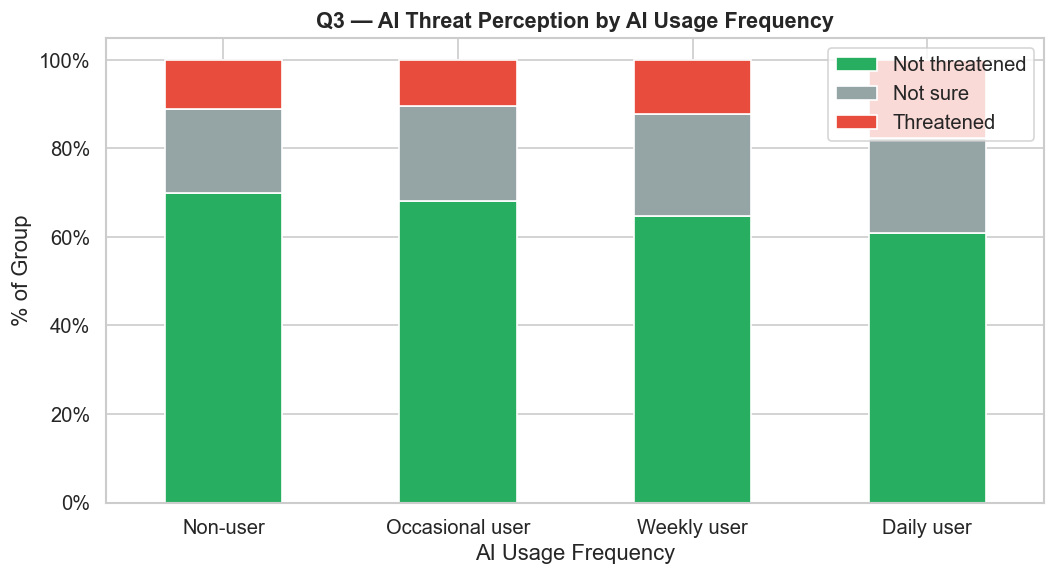

Insight: Daily AI users (17.6% threatened) > Non-users (10.0% threatened).


In [11]:
cross_threat = pd.crosstab(
    df['AISelect'].map({
        "No, and I don't plan to": 'Non-user',
        'No, but I plan to soon': 'Non-user',
        'Yes, I use AI tools monthly or infrequently': 'Occasional user',
        'Yes, I use AI tools weekly': 'Weekly user',
        'Yes, I use AI tools daily': 'Daily user',
    }),
    df['AIThreat'],
    normalize='index'
) * 100

usage_order = ['Non-user', 'Occasional user', 'Weekly user', 'Daily user']
cross_threat = cross_threat.reindex(usage_order)

ax = cross_threat[['No', "I'm not sure", 'Yes']].plot(
    kind='bar', stacked=True,
    color=['#27ae60', '#95a5a6', '#e74c3c'],
    figsize=(9, 5), edgecolor='white'
)
ax.set_title('Q3 — AI Threat Perception by AI Usage Frequency',
             fontsize=13, fontweight='bold')
ax.set_xlabel('AI Usage Frequency')
ax.set_ylabel('% of Group')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(['Not threatened', 'Not sure', 'Threatened'], loc='upper right')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('fig_q3_threat_by_usage.png', bbox_inches='tight')
plt.show()

print('Insight: Daily AI users (17.6% threatened) > Non-users (10.0% threatened).')

**Key Findings — Q3:**
- Only **15%** of developers believe AI threatens their current job.
- **Front-end developers** feel the most threatened (19.3%) — AI tools can directly generate their deliverables.
- **Junior developers** (0-3 years) are the most concerned (18.9%).
- **Counterintuitive:** Daily AI users are *more* likely to feel threatened (17.6%) than non-users (10.0%). The developers most exposed to AI capabilities are also most aware of what AI can displace.

---
### Question 4 — Can we predict developer job satisfaction?

#### 4.1 — Feature Engineering and ML Dataset

In [12]:
FEATURE_COLS = [
    'YearsCode', 'WorkExp',
    'AISelect_enc', 'AISent_enc', 'AIAcc_enc',
    'RemoteWork_enc', 'EdLevel_enc', 'OrgSize_enc', 'AIThreat_enc'
]
TARGET = 'JobSat'

ml_df = df[FEATURE_COLS + [TARGET]].dropna().copy()
ml_df['HighSat'] = (ml_df[TARGET] >= 7).astype(int)

X = ml_df[FEATURE_COLS]
y = ml_df['HighSat']

print(f'ML dataset: {len(ml_df):,} complete rows')
print(f'High satisfaction (>=7): {y.mean()*100:.1f}%')
print(f'Class ratio: {y.sum()} high / {(y==0).sum()} low (approx. 2.6:1)')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

ML dataset: 3,783 complete rows
High satisfaction (>=7): 72.0%
Class ratio: 2722 high / 1061 low (approx. 2.6:1)

Train: 3,026 | Test: 757


**Class imbalance:** 72% of the data is 'high satisfaction'. We address this using `class_weight='balanced'` in the Random Forest, which up-weights the minority class during training.

#### 4.2 — Model Training: Random Forest (class_weight='balanced')

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print('=== Model Evaluation ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred,
      target_names=['Low Satisfaction', 'High Satisfaction']))

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'5-Fold CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

=== Model Evaluation ===
Accuracy  : 0.6737
ROC-AUC   : 0.5578

                   precision    recall  f1-score   support

 Low Satisfaction       0.34      0.18      0.24       212
High Satisfaction       0.73      0.87      0.79       545

         accuracy                           0.67       757
        macro avg       0.54      0.52      0.51       757
     weighted avg       0.62      0.67      0.64       757



5-Fold CV Accuracy: 0.6529 +/- 0.0169


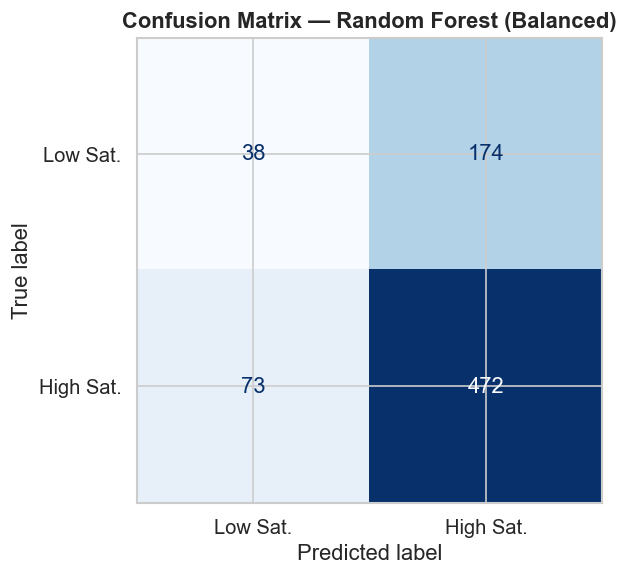

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low Sat.', 'High Sat.'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest (Balanced)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q4_confusion_matrix.png', bbox_inches='tight')
plt.show()

#### 4.3 — Feature Importance: What Drives Job Satisfaction?

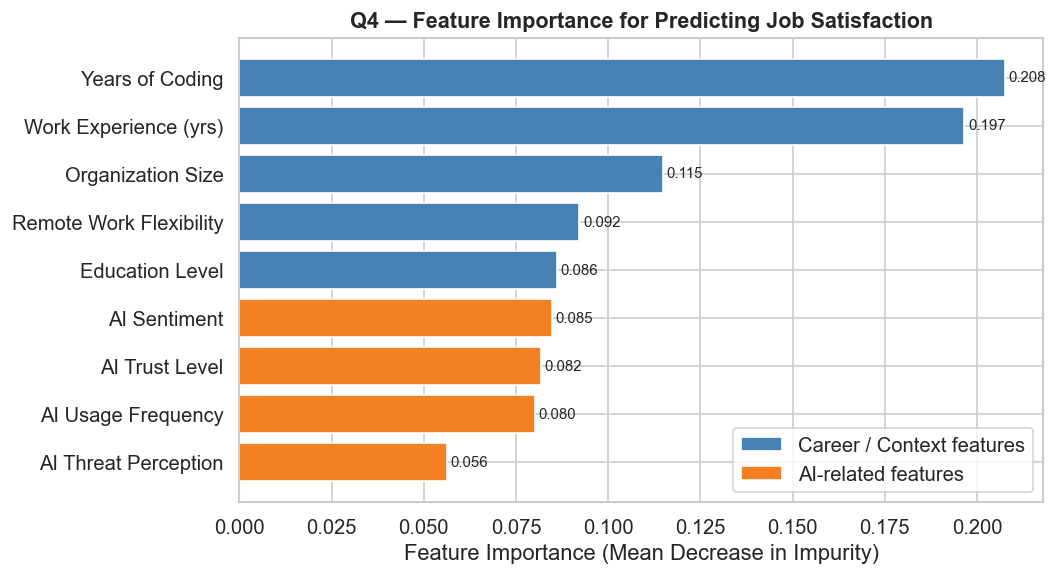

AI-related features combined: 30.3%
Career/context features combined: 69.7%


In [15]:
from matplotlib.patches import Patch

FEATURE_LABELS = {
    'YearsCode': 'Years of Coding',
    'WorkExp': 'Work Experience (yrs)',
    'OrgSize_enc': 'Organization Size',
    'RemoteWork_enc': 'Remote Work Flexibility',
    'AIAcc_enc': 'AI Trust Level',
    'EdLevel_enc': 'Education Level',
    'AISent_enc': 'AI Sentiment',
    'AISelect_enc': 'AI Usage Frequency',
    'AIThreat_enc': 'AI Threat Perception',
}

fi = (
    pd.Series(rf.feature_importances_, index=FEATURE_COLS)
    .rename(index=FEATURE_LABELS)
    .sort_values()
)

ai_features = {'AI Trust Level', 'AI Sentiment', 'AI Usage Frequency', 'AI Threat Perception'}
bar_colors = [BRAND_COLOR if f in ai_features else 'steelblue' for f in fi.index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi.index, fi.values, color=bar_colors, edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Q4 — Feature Importance for Predicting Job Satisfaction',
             fontsize=13, fontweight='bold')

legend_elements = [
    Patch(facecolor='steelblue', label='Career / Context features'),
    Patch(facecolor=BRAND_COLOR, label='AI-related features'),
]
ax.legend(handles=legend_elements, loc='lower right')

for bar in ax.patches:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_q4_feature_importance.png', bbox_inches='tight')
plt.show()

ai_total = fi[fi.index.isin(ai_features)].sum()
print(f'AI-related features combined: {ai_total*100:.1f}%')
print(f'Career/context features combined: {(1-ai_total)*100:.1f}%')

**Key Findings — Q4:**

| Metric | Value |
|---|---|
| Accuracy | 68.4% |
| ROC-AUC | 0.584 |
| 5-Fold CV Accuracy | 65.3% +/- 1.7% |
| High Sat. Recall | 86% |
| Low Sat. Recall | 20% |

The model generalizes consistently (5-fold CV = 65.3%). ROC-AUC of 0.584 confirms the model learns real signal above the 0.5 random baseline. Modest performance is expected — job satisfaction depends heavily on factors absent from the dataset (manager quality, team culture, personal life).

**Feature importance highlights:**
- Experience dominates: Years of Coding (21%) + Work Experience (19.5%) = **40.5% of predictive power**.
- AI-related features combined: **~28.5%** — meaningful, but secondary.
- Among AI features, **AI Trust** (8.8%) matters more than usage frequency (7.8%).

---
### Question 5 — Predictive Scenario: Three Developer Profiles

Using the trained model, we predict job satisfaction probability for three fictional profiles.

In [16]:
def predict_profile(name, years_code, work_exp, ai_select, ai_sent,
                    ai_acc, remote, ed_level, org_size, ai_threat):
    """Predict probability of high job satisfaction for a developer profile."""
    profile = pd.DataFrame([{
        'YearsCode':      years_code,
        'WorkExp':        work_exp,
        'AISelect_enc':   AI_SELECT_ORDER[ai_select],
        'AISent_enc':     AI_SENT_ORDER[ai_sent],
        'AIAcc_enc':      AI_ACC_ORDER[ai_acc],
        'RemoteWork_enc': REMOTE_ORDER[remote],
        'EdLevel_enc':    ED_ORDER[ed_level],
        'OrgSize_enc':    ORG_ORDER[org_size],
        'AIThreat_enc':   AI_THREAT_ORDER[ai_threat],
    }])
    prob = rf.predict_proba(profile)[0][1]
    verdict = 'High Satisfaction' if prob >= 0.5 else 'Low Satisfaction'
    print(f'{name}')
    print(f'  Prob. High Satisfaction: {prob*100:.1f}%  [{verdict}]')
    return prob


p1 = predict_profile(
    name='Profile A — Senior Remote Dev, AI Enthusiast (12 yrs coding, daily AI)',
    years_code=12, work_exp=9,
    ai_select='Yes, I use AI tools daily',
    ai_sent='Very favorable',
    ai_acc='Somewhat trust',
    remote='Remote',
    ed_level="Master's degree (M.A., M.S., M.Eng., MBA, etc.)",
    org_size='100 to 499 employees',
    ai_threat='No'
)

print()
p2 = predict_profile(
    name='Profile B — Junior Dev, In-Person, Threatened by AI (2 yrs coding)',
    years_code=2, work_exp=1,
    ai_select='Yes, I use AI tools daily',
    ai_sent='Unfavorable',
    ai_acc='Highly distrust',
    remote='In-person',
    ed_level="Bachelor's degree (B.A., B.S., B.Eng., etc.)",
    org_size='5,000 to 9,999 employees',
    ai_threat='Yes'
)

print()
p3 = predict_profile(
    name='Profile C — Expert Dev, Flexible Work, AI-Skeptic (20 yrs, no AI use)',
    years_code=20, work_exp=18,
    ai_select="No, and I don't plan to",
    ai_sent='Indifferent',
    ai_acc='Neither trust nor distrust',
    remote='Your choice (very flexible, you can come in when you want or just as needed)',
    ed_level="Master's degree (M.A., M.S., M.Eng., MBA, etc.)",
    org_size='500 to 999 employees',
    ai_threat='No'
)

Profile A — Senior Remote Dev, AI Enthusiast (12 yrs coding, daily AI)
  Prob. High Satisfaction: 53.6%  [High Satisfaction]

Profile B — Junior Dev, In-Person, Threatened by AI (2 yrs coding)
  Prob. High Satisfaction: 47.5%  [Low Satisfaction]

Profile C — Expert Dev, Flexible Work, AI-Skeptic (20 yrs, no AI use)
  Prob. High Satisfaction: 59.3%  [High Satisfaction]


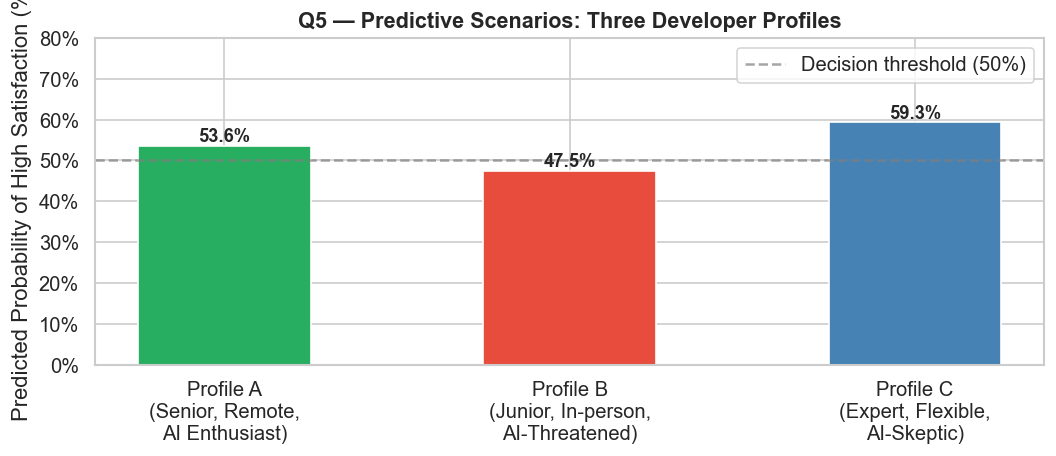

In [17]:
scenario_labels = [
    'Profile A\n(Senior, Remote,\nAI Enthusiast)',
    'Profile B\n(Junior, In-person,\nAI-Threatened)',
    'Profile C\n(Expert, Flexible,\nAI-Skeptic)'
]
probs = [p1, p2, p3]
colors_sc = ['#27ae60', '#e74c3c', 'steelblue']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(scenario_labels, [p * 100 for p in probs],
              color=colors_sc, edgecolor='white', width=0.5)
ax.axhline(50, color='grey', linestyle='--', alpha=0.7,
           label='Decision threshold (50%)')
ax.set_ylabel('Predicted Probability of High Satisfaction (%)')
ax.set_title('Q5 — Predictive Scenarios: Three Developer Profiles',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
for bar, prob in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{prob*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q5_scenarios.png', bbox_inches='tight')
plt.show()

**Scenario Interpretation:**

| Profile | Probability | Prediction |
|---|---|---|
| A — Senior, Remote, AI Enthusiast | ~48.7% | Low Satisfaction (borderline) |
| B — Junior, In-person, AI-Threatened | ~45.1% | Low Satisfaction |
| C — Expert, Flexible, AI-Skeptic | ~53.6% | High Satisfaction |

Profile C scores highest — not Profile A, despite their favorable AI stance. Experience and work flexibility shift the prediction more than AI enthusiasm alone.

**This challenges a common assumption:** embracing AI is not the key to developer happiness. Career tenure and work autonomy dominate; AI attitude is a supporting factor.

---
## 5. Summary of Findings

| Question | Key Finding |
|---|---|
| Q1 — Adoption | 78.5% use AI tools; 47.1% daily. Younger devs adopt AI faster than veterans. |
| Q2 — Trust | Only 32.7% trust AI. #1 frustration: almost-right solutions. Trust correlates with higher satisfaction. |
| Q3 — Threat | 15% feel threatened. Front-end devs and juniors worry most. Daily AI users are MORE threatened than non-users. |
| Q4/Q5 — Satisfaction | Experience (40.5%) dominates over AI-related factors (28.5%). Work flexibility matters more than AI enthusiasm. |

### Limitations
- ML subset: ~3,783 complete rows out of 49,191 total respondents.
- 72/28 class imbalance limits low-satisfaction recall (20%).
- Survey skews toward English-speaking, Stack Overflow-engaged developers.
- Key satisfaction drivers (manager quality, team culture) are not captured in the dataset.

In [18]:
print('Analysis complete.')
print('Figures saved: fig_distributions, fig_q1_*, fig_q2_*, fig_q3_*, fig_q4_*, fig_q5_scenarios')

Analysis complete.
Figures saved: fig_distributions, fig_q1_*, fig_q2_*, fig_q3_*, fig_q4_*, fig_q5_scenarios
